In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
License(s): CC0-1.0
 99% 557M/564M [00:03<00:00, 60.7MB/s]
100% 564M/564M [00:03<00:00, 172MB/s] 


In [ ]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/content/data/ultrasound breast classification/train"   # adjust if different
OUTPUT_PATH = "/content/data/ultrasound breast classification/train/train1"

# Classes in dataset
classes = ["benign","malignant"]

# Make sure output train folder exists
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Process each class
for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))  # replace spaces with underscore
    os.makedirs(dst_folder, exist_ok=True)

    # Get list of images
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle to randomize
    random.shuffle(images)

    # Take images
    selected_images = images[:1500]

    # Copy to train folder
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dst_folder, img))

    print(f"{cls}: {len(selected_images)} images copied to {dst_folder}")

print(" Train dataset prepared successfully!")

benign: 1500 images copied to /content/data/ultrasound breast classification/train/train1/benign
malignant: 1500 images copied to /content/data/ultrasound breast classification/train/train1/malignant
 Train dataset prepared successfully!


In [ ]:
train_dir = "/content/data/ultrasound breast classification/train/train1"

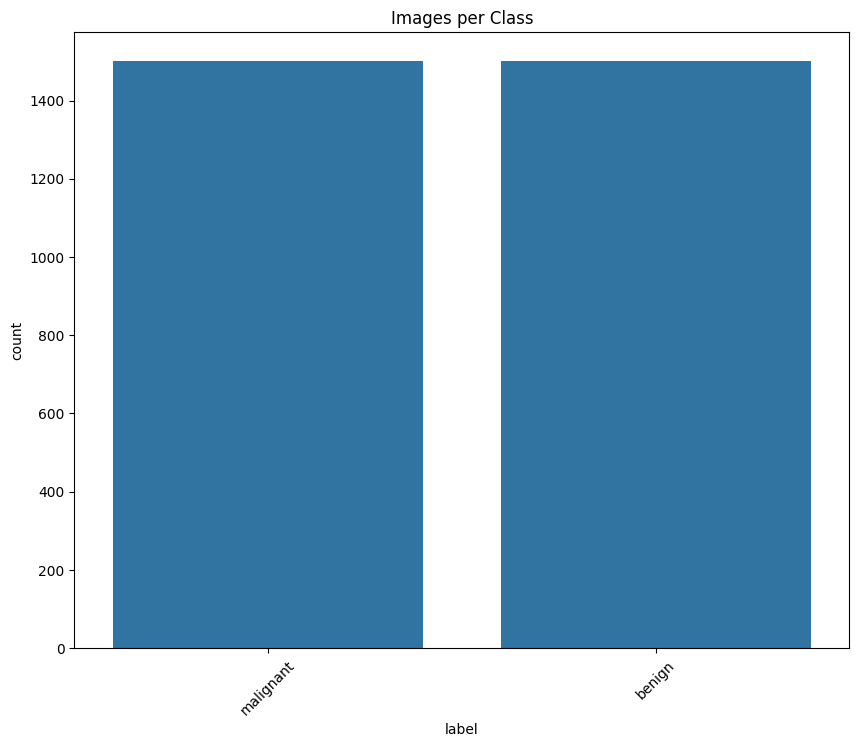

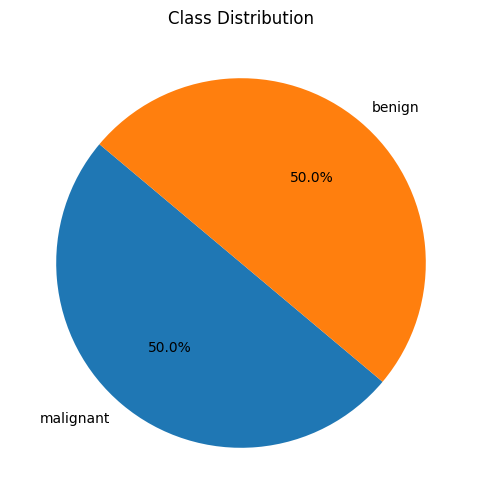

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Build DataFrame with filepaths and labels
df_balanced = pd.DataFrame()
for i, cls in enumerate(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    df_cls = pd.DataFrame({
        "filepath": [os.path.join(cls_path, img) for img in images],
        "label": cls,
        "label_num": str(i)  # numeric label as string
    })
    df_balanced = pd.concat([df_balanced, df_cls], ignore_index=True)

# Train (80%), temp (20%)
train_df, temp_df = train_test_split(
    df_balanced,
    train_size=0.8,
    shuffle=True,
    stratify=df_balanced['label_num'],
    random_state=42
)

# Validation (10%), Test (10%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    shuffle=True,
    stratify=temp_df['label_num'],
    random_state=42
)

# Check sizes
print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

# Class balance check
print("\nTrain class distribution:\n", train_df['label_num'].value_counts())
print("\nValidation class distribution:\n", valid_df['label_num'].value_counts())
print("\nTest class distribution:\n", test_df['label_num'].value_counts())

Train size: (2400, 3)
Validation size: (300, 3)
Test size: (300, 3)

Train class distribution:
 label_num
1    1200
0    1200
Name: count, dtype: int64

Validation class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64

Test class distribution:
 label_num
1    150
0    150
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 32
img_size = (224, 224)

tr_gen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=15,           # small rotations only
    width_shift_range=0.05,      # slight horizontal shifts
    height_shift_range=0.05,     # slight vertical shifts
    zoom_range=0.1,              # mild zoom
    horizontal_flip=True,        # flipping is okay for US images
    vertical_flip=False,         # usually vertical flip is not applied in US images
    shear_range=0.05,            # small shear
    fill_mode='nearest'          # fill empty pixels
    )

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepath', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='filepath', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size)

Found 2400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def create_mobilenetv2_simple(input_shape=(224,224,3), num_classes=2):
    inputs = Input(shape=input_shape)

    # Pretrained MobileNetV2 without top layers
    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

# Create and compile model
model = create_mobilenetv2_simple(num_classes=2)
model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/tmp/ipython-input-3612354510.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,047,746 (11.63 MB)

 Trainable params: 1,521,218 (5.80 MB)

 Non-trainable params: 1,526,528 (5.82 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks= callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5965 - loss: 0.8695
Epoch 1: val_accuracy improved from -inf to 0.57333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.5971 - loss: 0.8683 - val_accuracy: 0.5733 - val_loss: 0.6708 - learning_rate: 1.0000e-04
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6974 - loss: 0.6422
Epoch 2: val_accuracy improved from 0.57333 to 0.63333, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.6975 - loss: 0.6423 - val_accuracy: 0.6333 - val_loss: 0.6572 - learning_rate: 1.0000e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7229 - loss: 0.6130
Epoch 3: val_accuracy did not improve from 0.63333
75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7231 - loss: 0.6126 - val_accuracy: 0.6033 - val_loss: 0.7684 - learning_rate: 1.0000e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7683 - loss: 0.5596
Epoch 4: val_accuracy improved from 0.63333 to 0.71667, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7683 - loss: 0.5593 - val_accuracy: 0.7167 - val_loss: 0.6164 - learning_rate: 1.0000e-04
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7716 - loss: 0.5124
Epoch 5: val_accuracy did not improve from 0.71667
75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7716 - loss: 0.5125 - val_accuracy: 0.6800 - val_loss: 0.6414 - learning_rate: 1.0000e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7865 - loss: 0.4657
Epoch 6: val_accuracy did not improve from 0.71667
75/75 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.7865 - loss: 0.4657 - val_accuracy: 0.6233 - val_loss: 0.8438 - learning_rate: 1.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8108 - loss: 0.4306
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: val_accuracy did not improve from 0.71667
75/75 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8107 - loss: 0.4309 - val_accuracy:

75/75 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8167 - loss: 0.4136 - val_accuracy: 0.7433 - val_loss: 0.5824 - learning_rate: 5.0000e-05
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8185 - loss: 0.4169
Epoch 9: val_accuracy did not improve from 0.74333
75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8185 - loss: 0.4168 - val_accuracy: 0.7300 - val_loss: 0.5512 - learning_rate: 5.0000e-05
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7959 - loss: 0.4200
Epoch 10: val_accuracy did not improve from 0.74333
75/75 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7960 - loss: 0.4200 - val_accuracy: 0.7333 - val_loss: 0.5208 - learning_rate: 5.0000e-05
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8297 - loss: 0.3848
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 11: val_accuracy did not improve from 0.74333
75/75 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8296 - loss: 0.3849 - val_accu

75/75 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8237 - loss: 0.3922 - val_accuracy: 0.7567 - val_loss: 0.5455 - learning_rate: 2.5000e-05
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8375 - loss: 0.3671
Epoch 14: val_accuracy did not improve from 0.75667
75/75 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8374 - loss: 0.3672 - val_accuracy: 0.7567 - val_loss: 0.5182 - learning_rate: 2.5000e-05
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8482 - loss: 0.3660
Epoch 15: val_accuracy did not improve from 0.75667
75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8481 - loss: 0.3660 - val_accuracy: 0.7400 - val_loss: 0.5418 - learning_rate: 2.5000e-05
Epoch 16/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8359 - loss: 0.3521
Epoch 16: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.

Epoch 16: val_accuracy did not improve from 0.75667
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8359 - loss: 0.3522 - val_ac

75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8280 - loss: 0.4292 - val_accuracy: 0.7667 - val_loss: 0.5473 - learning_rate: 1.2500e-05
Epoch 18/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8526 - loss: 0.3387
Epoch 18: val_accuracy improved from 0.76667 to 0.78000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8525 - loss: 0.3388 - val_accuracy: 0.7800 - val_loss: 0.4975 - learning_rate: 1.2500e-05
Epoch 19/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8524 - loss: 0.3324
Epoch 19: val_accuracy improved from 0.78000 to 0.79000, saving model to best_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8523 - loss: 0.3327 - val_accuracy: 0.7900 - val_loss: 0.4759 - learning_rate: 1.2500e-05
Epoch 20/20
71/75 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8359 - loss: 0.3663

In [ ]:
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7830 - loss: 0.4592
Final Test Accuracy: 80.33%
Final Test Loss: 0.4545


In [ ]:
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

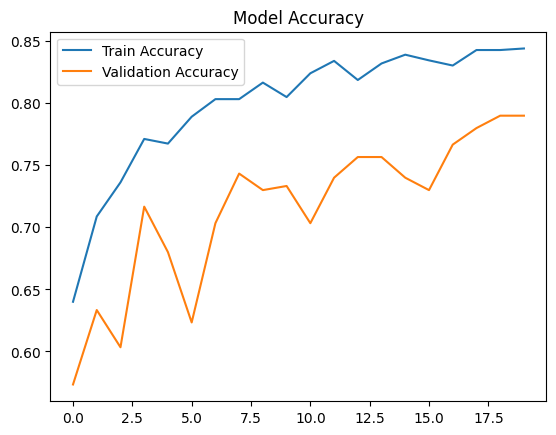

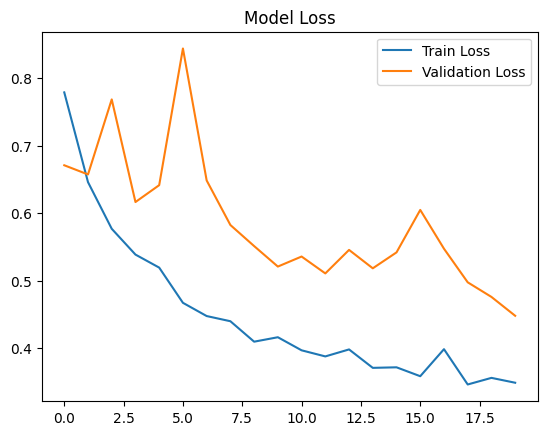

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77       150
           1       0.74      0.95      0.83       150

    accuracy                           0.80       300
   macro avg       0.83      0.80      0.80       300
weighted avg       0.83      0.80      0.80       300



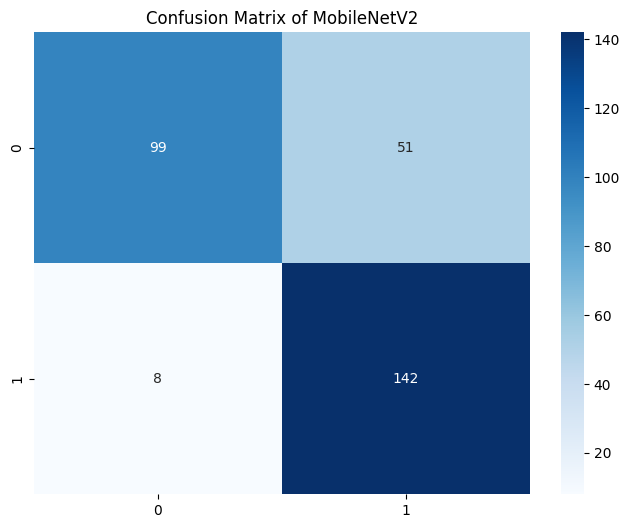

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNetV2")
plt.show()